## 3. Feature Engineering

### Goal
This section expands the original predictor set using domain-informed feature engineering. The aim is to capture mixture relationships, nonlinear effects, and interactions that may improve prediction of concrete compressive strength.

In [3]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import joblib
from pathlib import Path

from sklearn.model_selection import KFold, cross_validate
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import StandardScaler, RobustScaler
from sklearn.linear_model import RidgeCV
from sklearn.metrics import r2_score, mean_absolute_error, mean_squared_error
from sklearn.linear_model import LinearRegression, LassoCV, ElasticNetCV
from sklearn.ensemble import RandomForestRegressor, GradientBoostingRegressor

# Load bundled outputs from preprocessing notebook
bundle_path_candidates = [
    Path("/content/team6_preprocessed.joblib")
]

bundle_path = None
for path in bundle_path_candidates:
    if path.exists():
        bundle_path = path
        break

if bundle_path is None:
    raise FileNotFoundError(
        "Could not find team6_preprocessed.joblib. "
        "Check the save path in the preprocessing notebook."
    )

data = joblib.load(bundle_path)

X_train = data["X_train"].copy()
X_test = data["X_test"].copy()
y_train = data["y_train"].copy()
y_test = data["y_test"].copy()

# Safety: flatten y if it was saved as a one-column DataFrame
if isinstance(y_train, pd.DataFrame):
    y_train = y_train.iloc[:, 0]
if isinstance(y_test, pd.DataFrame):
    y_test = y_test.iloc[:, 0]

print("Loaded preprocessed bundle from:", bundle_path)
print("X_train:", X_train.shape)
print("X_test: ", X_test.shape)
print("y_train:", y_train.shape)
print("y_test: ", y_test.shape)

Loaded preprocessed bundle from: /content/team6_preprocessed.joblib
X_train: (804, 8)
X_test:  (201, 8)
y_train: (804,)
y_test:  (201,)


### Data Summary
The training and test sets were loaded successfully from the preprocessing output.

- `X_train` shape: `(804, 8)`
- `X_test` shape: `(201, 8)`
- `y_train` shape: `(804,)`
- `y_test` shape: `(201,)`

The predictor set contains **8 input features**, and all of them are **numeric**. There are **no categorical features** in this dataset, so categorical encoding is not required.

The original columns used as inputs for feature engineering are:

- `cement`
- `slag`
- `fly_ash`
- `water`
- `superplasticizer`
- `coarse_agg`
- `fine_agg`
- `age`

These variables are used to construct the engineered ratios, totals, nonlinear transforms, and interaction terms in Section 3.

### 3.1 Standardize and Validate Column Names
Column names are cleaned to make the dataset easier to reference and to keep feature formulas readable and consistent throughout the notebook. The training and test predictors are also checked to confirm that the expected columns are present and aligned before feature engineering begins.

In [4]:
def standardize_concrete_columns(df):
    df = df.copy()

    renamed = {}
    for col in df.columns:
        c = col.strip().lower()

        if "cement" in c and "component 1" in c:
            renamed[col] = "cement"
        elif "slag" in c:
            renamed[col] = "slag"
        elif "fly ash" in c or "fly_ash" in c:
            renamed[col] = "fly_ash"
        elif "water" in c and "component 4" in c:
            renamed[col] = "water"
        elif "superplasticizer" in c:
            renamed[col] = "superplasticizer"
        elif "coarse aggregate" in c:
            renamed[col] = "coarse_agg"
        elif "fine aggregate" in c:
            renamed[col] = "fine_agg"
        elif "age" in c:
            renamed[col] = "age"

    return df.rename(columns=renamed)

X_train = standardize_concrete_columns(X_train)
X_test = standardize_concrete_columns(X_test)

expected_cols = [
    "cement", "slag", "fly_ash", "water", "superplasticizer",
    "coarse_agg", "fine_agg", "age"
]

print("Training columns:")
print(X_train.columns.tolist())

print("\nTest columns:")
print(X_test.columns.tolist())

missing_train = [c for c in expected_cols if c not in X_train.columns]
missing_test = [c for c in expected_cols if c not in X_test.columns]

print("\nMissing expected columns in X_train:", missing_train)
print("Missing expected columns in X_test: ", missing_test)

assert missing_train == [], f"Missing columns in X_train: {missing_train}"
assert missing_test == [], f"Missing columns in X_test: {missing_test}"
assert list(X_train.columns) == list(X_test.columns), "Train/test columns do not match."

Training columns:
['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age']

Test columns:
['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age']

Missing expected columns in X_train: []
Missing expected columns in X_test:  []


### 3.1.1 Categorical Feature Check
The dataset was checked for categorical predictors before feature engineering. All predictors are numeric, so no categorical encoding step is required in this project.

In [5]:
numeric_cols = X_train.select_dtypes(include=[np.number]).columns.tolist()
categorical_cols = X_train.select_dtypes(include=["object", "category"]).columns.tolist()

print("Numeric columns:", numeric_cols)
print("Categorical columns:", categorical_cols)
print("Number of numeric features:", len(numeric_cols))
print("Number of categorical features:", len(categorical_cols))

assert len(categorical_cols) == 0, "Unexpected categorical columns found."

Numeric columns: ['cement', 'slag', 'fly_ash', 'water', 'superplasticizer', 'coarse_agg', 'fine_agg', 'age']
Categorical columns: []
Number of numeric features: 8
Number of categorical features: 0


### 3.2 Create Extended Feature Set
The original concrete mixture variables were expanded using domain-informed engineered features. The features were grouped into four main categories so the design is easier to interpret.

**1. Totals**  
Totals summarize broader parts of the concrete mixture, such as total binder, supplementary cementitious materials, total aggregate, and paste content. These variables help represent the overall composition of the mix in a more compact way.

**2. Ratios and proportion features**  
Ratio features capture relationships between ingredients, such as water-to-cement, water-to-binder, binder-to-water, admixture-to-binder, and fine-to-coarse aggregate balance. These are important because concrete strength is often driven more by relative proportions than by raw ingredient amounts alone.

**3. Nonlinear transformations**  
Nonlinear transforms such as logarithms, square roots, and squared terms are used to capture diminishing returns or curved relationships that may not be reflected by the original linear predictors. Age-related transforms are especially useful because strength development over time is not strictly linear.

**4. Interaction terms**  
Interaction features combine curing age with key material quantities, such as cement, water, and binder content. These terms are intended to capture the idea that the effect of a material amount may change depending on curing time.

All engineered features are created from the training and test predictors using the same deterministic formulas so that feature construction remains consistent across both datasets.

In [6]:
def add_engineered_features(X):
    X = X.copy()
    eps = 1e-6

    # Totals
    X["total_binder"] = X["cement"] + X["slag"] + X["fly_ash"]
    X["scm_total"] = X["slag"] + X["fly_ash"]
    X["aggregate_total"] = X["coarse_agg"] + X["fine_agg"]
    X["paste_total"] = (
        X["water"] + X["cement"] + X["slag"] + X["fly_ash"] + X["superplasticizer"]
    )

    # Water / binder relationships
    X["water_cement_ratio"] = X["water"] / (X["cement"] + eps)
    X["water_binder_ratio"] = X["water"] / (X["total_binder"] + eps)
    X["binder_water_ratio"] = X["total_binder"] / (X["water"] + eps)
    X["binder_minus_water"] = X["total_binder"] - X["water"]

    # Binder composition
    X["cement_binder_ratio"] = X["cement"] / (X["total_binder"] + eps)
    X["slag_binder_ratio"] = X["slag"] / (X["total_binder"] + eps)
    X["flyash_binder_ratio"] = X["fly_ash"] / (X["total_binder"] + eps)
    X["scm_binder_ratio"] = X["scm_total"] / (X["total_binder"] + eps)

    # Admixture ratios
    X["sp_cement_ratio"] = X["superplasticizer"] / (X["cement"] + eps)
    X["sp_binder_ratio"] = X["superplasticizer"] / (X["total_binder"] + eps)
    X["sp_water_ratio"] = X["superplasticizer"] / (X["water"] + eps)

    # Aggregate relationships
    X["fine_coarse_ratio"] = X["fine_agg"] / (X["coarse_agg"] + eps)
    X["coarse_fine_ratio"] = X["coarse_agg"] / (X["fine_agg"] + eps)
    X["aggregate_binder_ratio"] = X["aggregate_total"] / (X["total_binder"] + eps)
    X["paste_aggregate_ratio"] = X["paste_total"] / (X["aggregate_total"] + eps)
    X["fine_total_agg_ratio"] = X["fine_agg"] / (X["aggregate_total"] + eps)
    X["coarse_total_agg_ratio"] = X["coarse_agg"] / (X["aggregate_total"] + eps)

    # Nonlinear transforms
    X["log_age"] = np.log1p(X["age"])
    X["sqrt_age"] = np.sqrt(X["age"])
    X["age_squared"] = X["age"] ** 2

    X["log_cement"] = np.log1p(X["cement"])
    X["log_water"] = np.log1p(X["water"])
    X["log_superplasticizer"] = np.log1p(X["superplasticizer"])
    X["log_total_binder"] = np.log1p(X["total_binder"])

    # Interactions with age
    X["cement_x_age"] = X["cement"] * X["log_age"]
    X["water_x_age"] = X["water"] * X["log_age"]
    X["binder_x_age"] = X["total_binder"] * X["log_age"]
    X["sp_x_age"] = X["superplasticizer"] * X["log_age"]

    return X

In [7]:
X_train_fe = add_engineered_features(X_train)
X_test_fe = add_engineered_features(X_test)

print("Original feature count:  ", X_train.shape[1])
print("Engineered feature count:", X_train_fe.shape[1])

Original feature count:   8
Engineered feature count: 40


### Feature Set Size Note
The engineered feature set was intentionally expanded to explore several plausible domain-based relationships. Because this process can introduce overlapping predictors, a later pruning step is used to remove the most clearly redundant features while retaining the broader structure of the design.

### 3.3 Feature Review
The engineered predictors are reviewed to identify features that appear useful and to check for strong redundancy. Correlations with the target and among predictors help guide this assessment.

In [8]:
train_fe = X_train_fe.copy()
train_fe["strength"] = y_train.values

target_corr = (
    train_fe.corr(numeric_only=True)["strength"]
    .drop("strength")
    .sort_values(key=lambda s: s.abs(), ascending=False)
)

print("Top 20 absolute correlations with strength (train only):")
print(target_corr.head(20))

Top 20 absolute correlations with strength (train only):
binder_x_age              0.821229
cement_x_age              0.731135
binder_minus_water        0.635738
binder_water_ratio        0.633348
total_binder              0.614189
water_binder_ratio       -0.613293
log_total_binder          0.612746
paste_total               0.570331
log_age                   0.568408
aggregate_binder_ratio   -0.565132
sqrt_age                  0.543375
cement                    0.512440
water_cement_ratio       -0.506402
paste_aggregate_ratio     0.502867
log_cement                0.502192
age                       0.486019
sp_x_age                  0.454175
water_x_age               0.411581
age_squared               0.386944
sp_water_ratio            0.348993
Name: strength, dtype: float64


### Correlation Summary
The tables below report the three strongest and three weakest engineered predictors based on their correlation with compressive strength in the training data. Features are ranked by absolute correlation, while signed correlation values are reported for interpretation.

In [9]:
abs_corr = target_corr.abs().sort_values(ascending=False)

top3_features = abs_corr.head(3).index.tolist()
bottom3_features = abs_corr.sort_values(ascending=True).head(3).index.tolist()

top3_df = pd.DataFrame({
    "Feature": top3_features,
    "Correlation_with_strength": [target_corr[f] for f in top3_features]
})

bottom3_df = pd.DataFrame({
    "Feature": bottom3_features,
    "Correlation_with_strength": [target_corr[f] for f in bottom3_features]
})

print("Top 3 features by absolute correlation:")
display(top3_df)

print("Bottom 3 features by absolute correlation:")
display(bottom3_df)

Top 3 features by absolute correlation:


,Feature,Correlation_with_strength
0,binder_x_age,0.821229
1,cement_x_age,0.731135
2,binder_minus_water,0.635738


Bottom 3 features by absolute correlation:


,Feature,Correlation_with_strength
0,slag_binder_ratio,-0.004010
1,fine_coarse_ratio,-0.029405
2,scm_total,0.029566


In [10]:
corr_matrix = X_train_fe.corr(numeric_only=True).abs()

high_corr_pairs = []
cols = corr_matrix.columns

for i in range(len(cols)):
    for j in range(i + 1, len(cols)):
        r = corr_matrix.iloc[i, j]
        if r > 0.85:
            high_corr_pairs.append((cols[i], cols[j], r))

high_corr_pairs = sorted(high_corr_pairs, key=lambda x: x[2], reverse=True)

print("Highly correlated feature pairs (|r| > 0.85):")
for a, b, r in high_corr_pairs[:30]:
    print(f"{a:28s} {b:28s} r = {r:.3f}")

Highly correlated feature pairs (|r| > 0.85):
cement_binder_ratio          scm_binder_ratio             r = 1.000
fine_total_agg_ratio         coarse_total_agg_ratio       r = 1.000
water                        log_water                    r = 0.997
fine_coarse_ratio            coarse_total_agg_ratio       r = 0.996
fine_coarse_ratio            fine_total_agg_ratio         r = 0.996
coarse_fine_ratio            fine_total_agg_ratio         r = 0.993
coarse_fine_ratio            coarse_total_agg_ratio       r = 0.993
total_binder                 log_total_binder             r = 0.992
superplasticizer             sp_water_ratio               r = 0.988
total_binder                 paste_total                  r = 0.981
cement                       log_cement                   r = 0.981
paste_total                  paste_aggregate_ratio        r = 0.980
fine_coarse_ratio            coarse_fine_ratio            r = 0.978
aggregate_binder_ratio       log_total_binder             r = 0.977
to

### 3.4 Conservative Pruning
A conservative pruning step is used to remove only the most obviously overlapping engineered variables. The goal is to simplify the feature set without discarding predictors that may still contribute distinct information.

In [11]:
drop_cols = [
    "scm_total",
    "aggregate_total",
    "paste_total",
    "coarse_fine_ratio",
    "sqrt_age",
    "scm_binder_ratio",
    "coarse_total_agg_ratio",
    "log_water",
    "log_cement",
    "log_total_binder",
    "binder_water_ratio",
]

X_train_fe_pruned = X_train_fe.drop(columns=drop_cols, errors="ignore")
X_test_fe_pruned = X_test_fe.drop(columns=drop_cols, errors="ignore")

assert list(X_train_fe_pruned.columns) == list(X_test_fe_pruned.columns), \
    "Pruned train/test feature columns do not match."

print("Pruned feature count:", X_train_fe_pruned.shape[1])
print("Train shape:", X_train_fe_pruned.shape)
print("Test shape: ", X_test_fe_pruned.shape)

Pruned feature count: 29
Train shape: (804, 29)
Test shape:  (201, 29)


In [12]:
retained_features_df = pd.DataFrame({
    "Retained Features": X_train_fe_pruned.columns
})

retained_features_df

,Retained Features
0,cement
1,slag
2,fly_ash
3,water
4,superplasticizer
5,coarse_agg
6,fine_agg
7,age
8,total_binder
9,water_cement_ratio


In [13]:
def summarize_cv_scores(name, model, X, y, cv, scoring):
    scores = cross_validate(
        model,
        X,
        y,
        cv=cv,
        scoring=scoring,
        n_jobs=-1
    )

    return {
        "Model": name,
        "CV_R2_Mean": scores["test_r2"].mean(),
        "CV_R2_STD": scores["test_r2"].std(),
        "CV_RMSE_Mean": -scores["test_rmse"].mean(),
        "CV_MAE_Mean": -scores["test_mae"].mean()
    }

### 3.5 Baseline vs Engineered Features (CV Only)
The original and engineered feature sets are compared using five-fold cross-validation on the training data. This provides a fair estimate of whether feature engineering improves predictive performance before moving on to final model comparison.

In [14]:
alphas = np.logspace(-3, 3, 50)

baseline_std = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas))
])

engineered_std = Pipeline([
    ("scaler", StandardScaler()),
    ("ridge", RidgeCV(alphas=alphas))
])

engineered_robust = Pipeline([
    ("scaler", RobustScaler()),
    ("ridge", RidgeCV(alphas=alphas))
])

In [15]:
cv_5 = KFold(n_splits=5, shuffle=True, random_state=42)

scoring = {
    "r2": "r2",
    "rmse": "neg_root_mean_squared_error",
    "mae": "neg_mean_absolute_error"
}

results = []

results.append(
    summarize_cv_scores(
        "Baseline + StandardScaler",
        baseline_std,
        X_train,
        y_train,
        cv_5,
        scoring
    )
)

results.append(
    summarize_cv_scores(
        "Engineered + StandardScaler",
        engineered_std,
        X_train_fe_pruned,
        y_train,
        cv_5,
        scoring
    )
)

results.append(
    summarize_cv_scores(
        "Engineered + RobustScaler",
        engineered_robust,
        X_train_fe_pruned,
        y_train,
        cv_5,
        scoring
    )
)

results_df = pd.DataFrame(results).sort_values(
    by=["CV_RMSE_Mean", "CV_R2_Mean"],
    ascending=[True, False]
)

results_df

,Model,CV_R2_Mean,CV_R2_STD,CV_RMSE_Mean,CV_MAE_Mean
1,Engineered + StandardScaler,0.847407,0.029930,6.362177,4.779912
2,Engineered + RobustScaler,0.847350,0.029705,6.363973,4.778359
0,Baseline + StandardScaler,0.737091,0.052369,8.361877,6.516259


In [16]:
baseline_std.fit(X_train, y_train)
engineered_std.fit(X_train_fe_pruned, y_train)
engineered_robust.fit(X_train_fe_pruned, y_train)

print("Best alpha values (fit on training data only):")
print("Baseline + StandardScaler: ", baseline_std.named_steps["ridge"].alpha_)
print("Engineered + StandardScaler:", engineered_std.named_steps["ridge"].alpha_)
print("Engineered + RobustScaler: ", engineered_robust.named_steps["ridge"].alpha_)

Best alpha values (fit on training data only):
Baseline + StandardScaler:  0.868511373751352
Engineered + StandardScaler: 0.28117686979742307
Engineered + RobustScaler:  0.1206792640639329


### 3.5.1 Final Scaling for Saved Modeling Datasets
Cross-validation above uses scaling inside the pipeline to avoid leakage across folds. After selecting the retained engineered features, an explicit scaler is fit on `X_train_fe_pruned` and applied to both train and test sets so the final scaled modeling datasets can be saved for downstream use.

In [17]:
final_scaler = StandardScaler()

X_train_fe_pruned_scaled = pd.DataFrame(
    final_scaler.fit_transform(X_train_fe_pruned),
    columns=X_train_fe_pruned.columns,
    index=X_train_fe_pruned.index
)

X_test_fe_pruned_scaled = pd.DataFrame(
    final_scaler.transform(X_test_fe_pruned),
    columns=X_test_fe_pruned.columns,
    index=X_test_fe_pruned.index
)

print("Scaled train shape:", X_train_fe_pruned_scaled.shape)
print("Scaled test shape: ", X_test_fe_pruned_scaled.shape)

print("\nLargest absolute mean in scaled training features:")
print(X_train_fe_pruned_scaled.mean().abs().max())

print("\nFirst 10 scaled training means:")
print(X_train_fe_pruned_scaled.mean().head(10))

Scaled train shape: (804, 29)
Scaled test shape:  (201, 29)

Largest absolute mean in scaled training features:
2.0679975145256648e-15

First 10 scaled training means:
cement               -6.849137e-17
slag                 -4.418798e-18
fly_ash              -8.837596e-18
water                 7.357299e-16
superplasticizer      6.628197e-17
coarse_agg           -1.626118e-15
fine_agg             -2.067998e-15
age                  -1.104700e-17
total_binder          6.561915e-16
water_cement_ratio   -1.369827e-16
dtype: float64


### 3.6 Visualization
The chart below highlights the engineered predictors that show the strongest linear association with compressive strength in the training data. This provides a quick view of which transformed variables appear most informative.

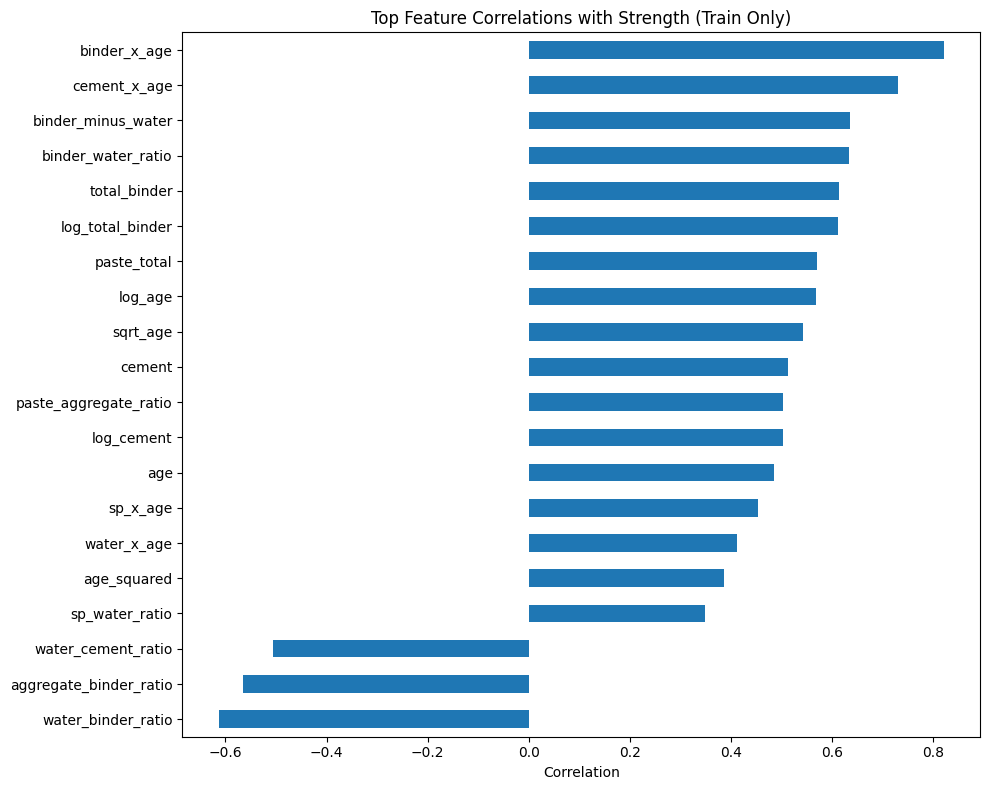

In [18]:
plt.figure(figsize=(10, 8))
target_corr.head(20).sort_values().plot(kind="barh")
plt.title("Top Feature Correlations with Strength (Train Only)")
plt.xlabel("Correlation")
plt.tight_layout()
plt.show()

### 3.7 Save Final Feature Sets
The original, engineered, pruned, and scaled feature sets are saved so the downstream modeling notebook can reuse the exact same train/test artifacts without recomputing feature engineering steps.

In [20]:
feature_bundle = {
    "X_train_original": X_train,
    "X_test_original": X_test,
    "X_train_fe": X_train_fe,
    "X_test_fe": X_test_fe,
    "X_train_fe_pruned": X_train_fe_pruned,
    "X_test_fe_pruned": X_test_fe_pruned,
    "X_train_fe_pruned_scaled": X_train_fe_pruned_scaled,
    "X_test_fe_pruned_scaled": X_test_fe_pruned_scaled,
    "y_train": y_train,
    "y_test": y_test,
    "retained_feature_names": list(X_train_fe_pruned.columns),
    "dropped_feature_names": drop_cols,
    "scaler": final_scaler,
}

joblib.dump(feature_bundle, "/content/team6_feature_engineering.joblib")
print("Saved feature engineering bundle to /content/team6_feature_engineering.joblib")

Saved feature engineering bundle to /content/team6_feature_engineering.joblib


### Feature Engineering Results
The original concrete mixture variables were expanded using domain-informed engineered features, including ratios, totals, nonlinear transformations, and interaction terms. This produced a broader predictor set designed to better capture the relationships among mixture components and their influence on compressive strength.

The engineered features were reviewed using correlation analysis and then conservatively pruned to remove the most clearly redundant variables. This reduced the feature set from 40 predictors to 29 while preserving predictors that appeared to contribute distinct and useful information.

Performance of the original and engineered feature sets was then compared using five-fold cross-validation with Ridge regression. The engineered features improved performance over the baseline feature set, increasing cross-validated R² from approximately 0.737 to 0.847 and reducing cross-validated RMSE from about 8.36 to 6.36. StandardScaler and RobustScaler produced nearly identical results, so StandardScaler was retained for simplicity.

Overall, the engineered feature set added meaningful predictive value and provided a much stronger foundation for future regression modeling.